In [1]:
!git clone https://github.com/venkatsaikondra/CNN_ViT_Hybrid_Vit_Research_Pneumonia_4_Classification.git

Cloning into 'CNN_ViT_Hybrid_Vit_Research_Pneumonia_4_Classification'...
remote: Enumerating objects: 43718, done.
remote: Counting objects: 100% (91/91), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 43718 (delta 42), reused 65 (delta 23), pack-reused 43627 (from 3)
Receiving objects: 100% (43718/43718), 487.85 MiB | 23.90 MiB/s, done.
Resolving deltas: 100% (120/120), done.
Updating files: 100% (119007/119007), done.


In [2]:
!pip install transformers[tf]

In [3]:
!pip install timm

In [13]:
import os
import torch
import torch.nn as nn
import timm
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from PIL import Image
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from timm.data import create_transform

# --- 1. Configuration ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE_DIR = '/content/CNN_ViT_Hybrid_Vit_Research_Pneumonia_4_Classification/Train_Test_Split_Vit_Data'
train_data_dir = os.path.join(BASE_DIR, 'train')
val_data_dir = os.path.join(BASE_DIR, 'val')

# --- 2. Initialize BoTNet via timm ---
# 'botnet26t_256' is a known BoTNet variant in timm
model_botnet = timm.create_model('botnet26t_256', pretrained=True, num_classes=4)
model_botnet.to(device)

# --- 3. Preprocessing (Standard for BoTNet/ResNet) ---
# Use timm's create_transform to ensure correct preprocessing for the model
data_transforms = create_transform(
    input_size=model_botnet.default_cfg['input_size'][1], # Use model's expected input size (256)
    is_training=True, # Apply training augmentations if needed
    mean=model_botnet.default_cfg['mean'],
    std=model_botnet.default_cfg['std'],
    interpolation=model_botnet.default_cfg['interpolation'],
)
# Validation transform (no random augmentations)
val_transforms = create_transform(
    input_size=model_botnet.default_cfg['input_size'][1],
    is_training=False,
    mean=model_botnet.default_cfg['mean'],
    std=model_botnet.default_cfg['std'],
    interpolation=model_botnet.default_cfg['interpolation'],
)


# --- 4. Dataset Class ---
class PneumoniaDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
        self.class_to_idx = {name: i for i, name in enumerate(self.classes)}

        for class_name in self.classes:
            path = os.path.join(data_dir, class_name)
            for img in os.listdir(path):
                if img.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(path, img))
                    self.labels.append(self.class_to_idx[class_name])

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(self.labels[idx])

# Create Dataloaders
train_dataloader = DataLoader(PneumoniaDataset(train_data_dir, data_transforms), batch_size=32, shuffle=True)
val_dataloader = DataLoader(PneumoniaDataset(val_data_dir, val_transforms), batch_size=32, shuffle=False)

# --- 5. Training Setup ---
optimizer = AdamW(model_botnet.parameters(), lr=1e-4) # BoTNet can handle slightly higher LR than ViT
criterion = nn.CrossEntropyLoss()

In [14]:
epochs = 25
print(f"Starting BoTNet Training on {device}...")

for epoch in range(epochs):
    model_botnet.train()
    train_loss, correct, total = 0, 0, 0
    for inputs, labels in train_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_botnet(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    # Validation Phase
    model_botnet.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for v_inputs, v_labels in val_dataloader:
            v_inputs, v_labels = v_inputs.to(device), v_labels.to(device)
            v_outputs = model_botnet(v_inputs)
            _, v_pred = v_outputs.max(1)
            val_total += v_labels.size(0)
            val_correct += v_pred.eq(v_labels).sum().item()

    print(f"BoTNet Epoch {epoch+1}/{epochs} | Loss: {train_loss/len(train_dataloader):.4f} | "
          f"Train Acc: {100.*correct/total:.2f}% | Val Acc: {100.*val_correct/val_total:.2f}%")

Starting BoTNet Training on cuda...
BoTNet Epoch 1/25 | Loss: 0.7003 | Train Acc: 70.80% | Val Acc: 81.40%
BoTNet Epoch 2/25 | Loss: 0.5429 | Train Acc: 77.35% | Val Acc: 83.58%
BoTNet Epoch 3/25 | Loss: 0.4932 | Train Acc: 79.57% | Val Acc: 85.16%
BoTNet Epoch 4/25 | Loss: 0.4575 | Train Acc: 81.03% | Val Acc: 86.97%
BoTNet Epoch 5/25 | Loss: 0.4337 | Train Acc: 82.07% | Val Acc: 89.10%
BoTNet Epoch 6/25 | Loss: 0.4125 | Train Acc: 82.80% | Val Acc: 86.78%
BoTNet Epoch 7/25 | Loss: 0.3867 | Train Acc: 84.19% | Val Acc: 88.54%
BoTNet Epoch 8/25 | Loss: 0.3646 | Train Acc: 84.77% | Val Acc: 89.89%
BoTNet Epoch 9/25 | Loss: 0.3419 | Train Acc: 86.02% | Val Acc: 90.68%
BoTNet Epoch 10/25 | Loss: 0.3369 | Train Acc: 86.05% | Val Acc: 91.84%
BoTNet Epoch 11/25 | Loss: 0.3199 | Train Acc: 86.66% | Val Acc: 92.63%
BoTNet Epoch 12/25 | Loss: 0.2957 | Train Acc: 88.26% | Val Acc: 92.49%
BoTNet Epoch 13/25 | Loss: 0.2829 | Train Acc: 88.52% | Val Acc: 93.23%
BoTNet Epoch 14/25 | Loss: 0.2736 | T

In [22]:
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np # Import numpy for array operations

class RISE_Explainer(nn.Module):
    def __init__(self, model, input_size=(384, 384), gpu_batch=16):
        super().__init__()
        self.model = model
        self.input_size = input_size
        self.gpu_batch = gpu_batch

    def generate_masks(self, N, s, p1):
        """Generates random masks for sampling."""
        cell_size = np.ceil(np.array(self.input_size) / s)
        up_size = (s + 1) * cell_size

        grid = np.random.rand(N, s, s) < p1
        grid = grid.astype('float32')

        masks = np.empty((N, *self.input_size))
        for i in range(N):
            # Bilinear upsampling and random cropping for jitter
            x = np.random.randint(0, cell_size[0])
            y = np.random.randint(0, cell_size[1])
            masks[i] = self._upsample(grid[i], up_size)[x:x+self.input_size[0], y:y+self.input_size[1]]

        return torch.from_numpy(masks).float().to(device)

    def _upsample(self, grid, up_size):
        # Helper for bilinear interpolation
        img = Image.fromarray(grid)
        return np.array(img.resize((int(up_size[1]), int(up_size[0])), resample=Image.BILINEAR))

    def explain(self, x, N=1000, s=8, p1=0.5):
        """Generates the saliency map for a given image x."""
        self.model.eval()
        masks = self.generate_masks(N, s, p1)

        # Multiply image by masks and run through model
        stack = []
        for i in range(0, N, self.gpu_batch):
            m = masks[i:i+self.gpu_batch].unsqueeze(1)
            masked_x = x * m
            with torch.no_grad():
                # Removed .logits as the model directly returns the output tensor
                logits = self.model(masked_x)
                stack.append(torch.softmax(logits, dim=1))

        predictions = torch.cat(stack) # (N, num_classes)

        # Weighted sum of masks based on prediction confidence
        sal = torch.matmul(predictions.data.transpose(0, 1), masks.view(N, -1))
        sal = sal.view(-1, *self.input_size)
        return sal / N / p1

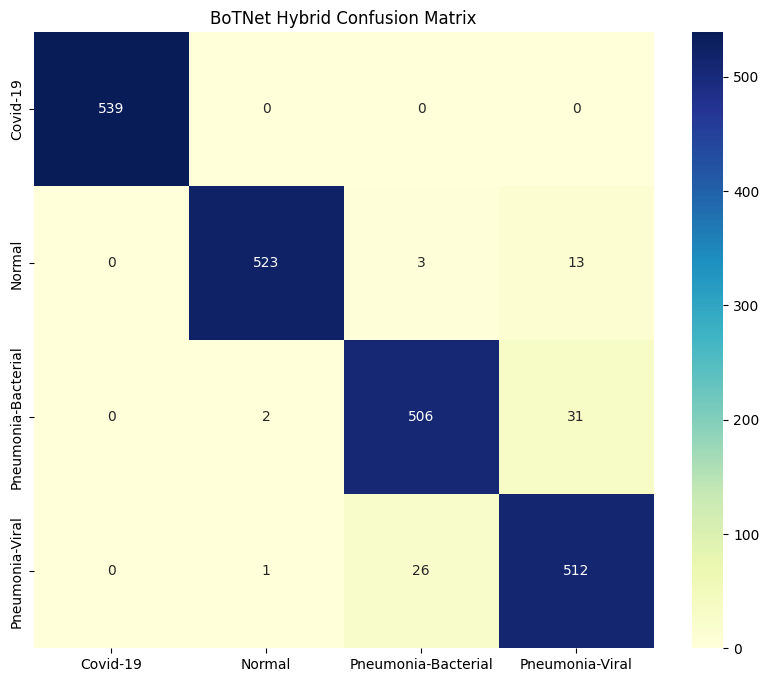


BoTNet Classification Report:

                     precision    recall  f1-score   support

           Covid-19       1.00      1.00      1.00       539
             Normal       0.99      0.97      0.98       539
Pneumonia-Bacterial       0.95      0.94      0.94       539
    Pneumonia-Viral       0.92      0.95      0.94       539

           accuracy                           0.96      2156
          macro avg       0.97      0.96      0.96      2156
       weighted avg       0.97      0.96      0.96      2156



In [15]:
model_botnet.eval()
all_preds, all_labels = [], []
class_names = ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']

with torch.no_grad():
    for inputs, labels in val_dataloader:
        outputs = model_botnet(inputs.to(device))
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=class_names, yticklabels=class_names)
plt.title('BoTNet Hybrid Confusion Matrix')
plt.show()

print("\nBoTNet Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

Generating Research Visuals for: /content/CNN_ViT_Hybrid_Vit_Research_Pneumonia_4_Classification/Train_Test_Split_Vit_Data/val/Pneumonia-Bacterial/base_Pneumonia-Bacterial (2279).jpg


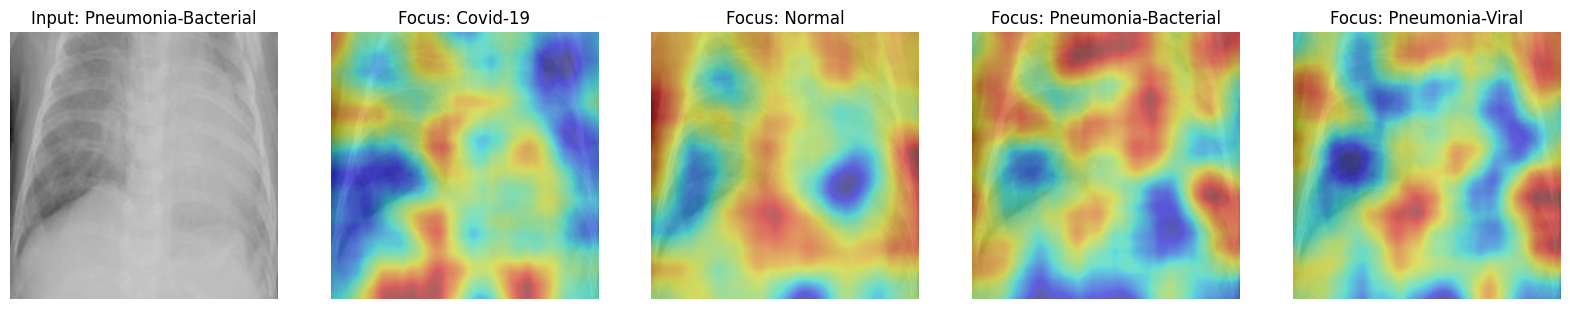

In [23]:
import os
import random
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# --- 1. Define Paths and Class Names ---
# Ensuring variables match your 4-pathogen research granularity
class_names = ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']
target_class = 'Pneumonia-Bacterial'
class_folder = os.path.join(val_data_dir, target_class)

# Correctly defining the previously missing path
random_image = random.choice(os.listdir(class_folder))
some_test_image_path = os.path.join(class_folder, random_image)

# --- 2. BoTNet Explainability Function ---
def visualize_botnet_explainability(model, image_path, class_names):
    """
    Generates RISE saliency maps to show where BoTNet focuses for each pathogen.
    """
    model.eval()
    # Ensure consistent input size for original image and explainer
    orig_img = Image.open(image_path).convert('RGB').resize((256, 256))

    # Apply the same transforms used during BoTNet training
    x = data_transforms(orig_img).unsqueeze(0).to(device)

    # Initialize RISE with BoTNet's specific input size (now 256x256)
    explainer = RISE_Explainer(model, input_size=(256, 256))
    saliency_maps = explainer.explain(x)

    # Plotting the 4-class granularity results
    plt.figure(figsize=(20, 5))
    plt.subplot(1, 5, 1)
    plt.imshow(orig_img)
    plt.title(f"Input: {target_class}")
    plt.axis('off')

    for i in range(4):
        plt.subplot(1, 5, i+2)
        plt.imshow(orig_img)
        # 'jet' colormap highlights the specific lung textures identified by the model
        plt.imshow(saliency_maps[i].cpu(), cmap='jet', alpha=0.5)
        plt.title(f"Focus: {class_names[i]}")
        plt.axis('off')

    plt.show()

# --- 3. Execution ---
print(f"Generating Research Visuals for: {some_test_image_path}")
visualize_botnet_explainability(model_botnet, some_test_image_path, class_names)


Generating Research Visuals for: /content/CNN_ViT_Hybrid_Vit_Research_Pneumonia_4_Classification/Train_Test_Split_Vit_Data/val/Pneumonia-Bacterial/base_Pneumonia-Bacterial (1415).jpg


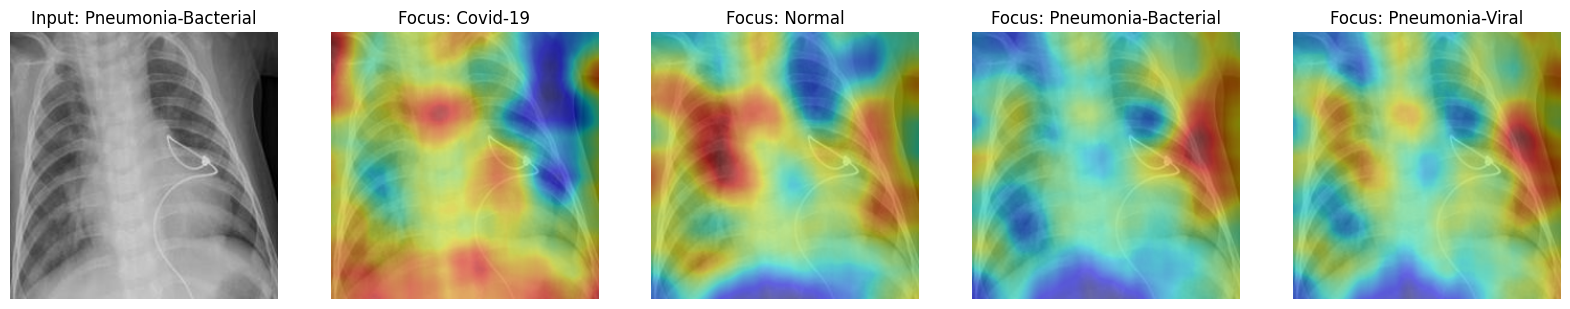

In [24]:
import os
import random
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# --- 1. Define Paths and Class Names ---
# Ensuring variables match your 4-pathogen research granularity
class_names = ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']
target_class = 'Pneumonia-Bacterial'
class_folder = os.path.join(val_data_dir, target_class)

# Correctly defining the previously missing path
random_image = random.choice(os.listdir(class_folder))
some_test_image_path = os.path.join(class_folder, random_image)

# --- 2. BoTNet Explainability Function ---
def visualize_botnet_explainability(model, image_path, class_names):
    """
    Generates RISE saliency maps to show where BoTNet focuses for each pathogen.
    """
    model.eval()
    # Ensure consistent input size for original image and explainer
    orig_img = Image.open(image_path).convert('RGB').resize((256, 256))

    # Apply the same transforms used during BoTNet training
    x = data_transforms(orig_img).unsqueeze(0).to(device)

    # Initialize RISE with BoTNet's specific input size (now 256x256)
    explainer = RISE_Explainer(model, input_size=(256, 256))
    saliency_maps = explainer.explain(x)

    # Plotting the 4-class granularity results
    plt.figure(figsize=(20, 5))
    plt.subplot(1, 5, 1)
    plt.imshow(orig_img)
    plt.title(f"Input: {target_class}")
    plt.axis('off')

    for i in range(4):
        plt.subplot(1, 5, i+2)
        plt.imshow(orig_img)
        # 'jet' colormap highlights the specific lung textures identified by the model
        plt.imshow(saliency_maps[i].cpu(), cmap='jet', alpha=0.5)
        plt.title(f"Focus: {class_names[i]}")
        plt.axis('off')

    plt.show()

# --- 3. Execution ---
print(f"Generating Research Visuals for: {some_test_image_path}")
visualize_botnet_explainability(model_botnet, some_test_image_path, class_names)